In [4]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [6]:
from proj2dhullsampler.hm_class import (
    meta_one_hot_shot,
    EmulatedDataStorage,
    HistoryMatching)

from proj2dhullsampler.plotting import *

In [7]:
from proj2dhullsampler.sampling_functions import *

In [8]:
working_dir = '/glade/work/qingyuany/gfdl_esm'
case_name = "v2_test2"

ppe_para = pd.read_csv("/glade/work/qingyuany/gfdl_esm/v2/gfdl_v2_para.csv", index_col=False)




In [9]:
test_case = HistoryMatching(working_dir, case_name, ppe_para, threshold_level = 2.5)
test_case.drop_by_name(["TGCLDLWP", "CLDTOT"])
test_case.drop_by_n_survive(n_survive = 500)
test_case.update_meta()



In [10]:
len(test_case.dropped_vars.tight) + len(test_case.dropped_vars.by_name) + len(test_case.dropped_vars.nooverlap2d) 

18

In [11]:
test_case.dropped_vars.tight

['Cloud_Top_Pressure_MODIS',
 '850mb_Temperature',
 'Liquid_Tau_MODIS',
 '200mb_Wind',
 'Land_Surface_Temperature',
 'Liquid_Radius_MODIS',
 'Ice_Radius_MODIS',
 'Low_Cloud_Fraction_MODIS',
 '850mb_Wind',
 '250mb_Temperature',
 'Mid_Cloud_Fraction_MODIS',
 '500mb_Temperature',
 'Liquid_Water_Path_MODIS',
 'Total_Tau_MODIS',
 'Sfc_Ocean_Winds',
 'Surface_Albedo',
 '850mb_Specific_Humidity',
 '500mb_Geopotential_Height']

In [12]:
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()

auto_th0                                 and rkm_sh                                  :   392264
qcvar                                    and accretion_scale                         :   331318
liq_max_radi                             and peff_l_d                                :     9070
rkm_dp1                                  and rkm_dp2                                 :   444258
Nimax_heteo                              and ck1                                     :   537480
tau_dp                                   and kt_tke_ed_min                           :   890744
gamma_distribution_param                 and tau_dp                                  :   129723
dcs                                      and liq_max_radi                            :   446656
tau_dp                                   and auto_th0                                :    85598
tau_dp                                   and rkm_sh                                  :   365678
There are 1 groups that have no overlapp

In [14]:
list(summary2d.values())[0]

,var1,var2,count


In [17]:
no_overlap_2d_vars = []

In [18]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()
summary2d

auto_th0                                 and rkm_sh                                  :   392264
qcvar                                    and accretion_scale                         :   331318
liq_max_radi                             and peff_l_d                                :     9070
rkm_dp1                                  and rkm_dp2                                 :   444258
Nimax_heteo                              and ck1                                     :   537480
tau_dp                                   and kt_tke_ed_min                           :   890744
gamma_distribution_param                 and tau_dp                                  :   129723
dcs                                      and liq_max_radi                            :   446656
tau_dp                                   and auto_th0                                :    85598
tau_dp                                   and rkm_sh                                  :   365678
There are 1 groups that have no overlapp

{('liq_max_radi',
  'peff_l_d'): Empty DataFrame
 Columns: [var1, var2, count]
 Index: []}

In [19]:
test_case.build_hulls()

In [21]:
test_case.orchestrate()

Running ('auto_th0', 'rkm_sh'), the 0th simulation
There is overlap for ('auto_th0', 'rkm_sh'). Proceed to the next parameter pair
Running ('qcvar', 'accretion_scale'), the 1th simulation
There is overlap for ('qcvar', 'accretion_scale'). Proceed to the next parameter pair
Running ('liq_max_radi', 'peff_l_d'), the 2th simulation
There is overlap for ('liq_max_radi', 'peff_l_d'). Proceed to the next parameter pair
Running ('rkm_dp1', 'rkm_dp2'), the 3th simulation
There is overlap for ('rkm_dp1', 'rkm_dp2'). Proceed to the next parameter pair
Running ('Nimax_heteo', 'ck1'), the 4th simulation
There is overlap for ('Nimax_heteo', 'ck1'). Proceed to the next parameter pair
Running ('tau_dp', 'kt_tke_ed_min'), the 5th simulation
There is overlap for ('tau_dp', 'kt_tke_ed_min'). Proceed to the next parameter pair
Running ('gamma_distribution_param', 'tau_dp'), the 6th simulation
There is overlap for ('gamma_distribution_param', 'tau_dp'). Proceed to the next parameter pair
Running ('dcs', '

In [23]:
test_case.draw(n_pts=50000, n_threshold=5000, sample_threshold=10**8, max_workers=10, n_max=1000)

In [24]:
test_case.save_samples(n = 100)
test_case.write_specifications()

(379, 44)
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '1

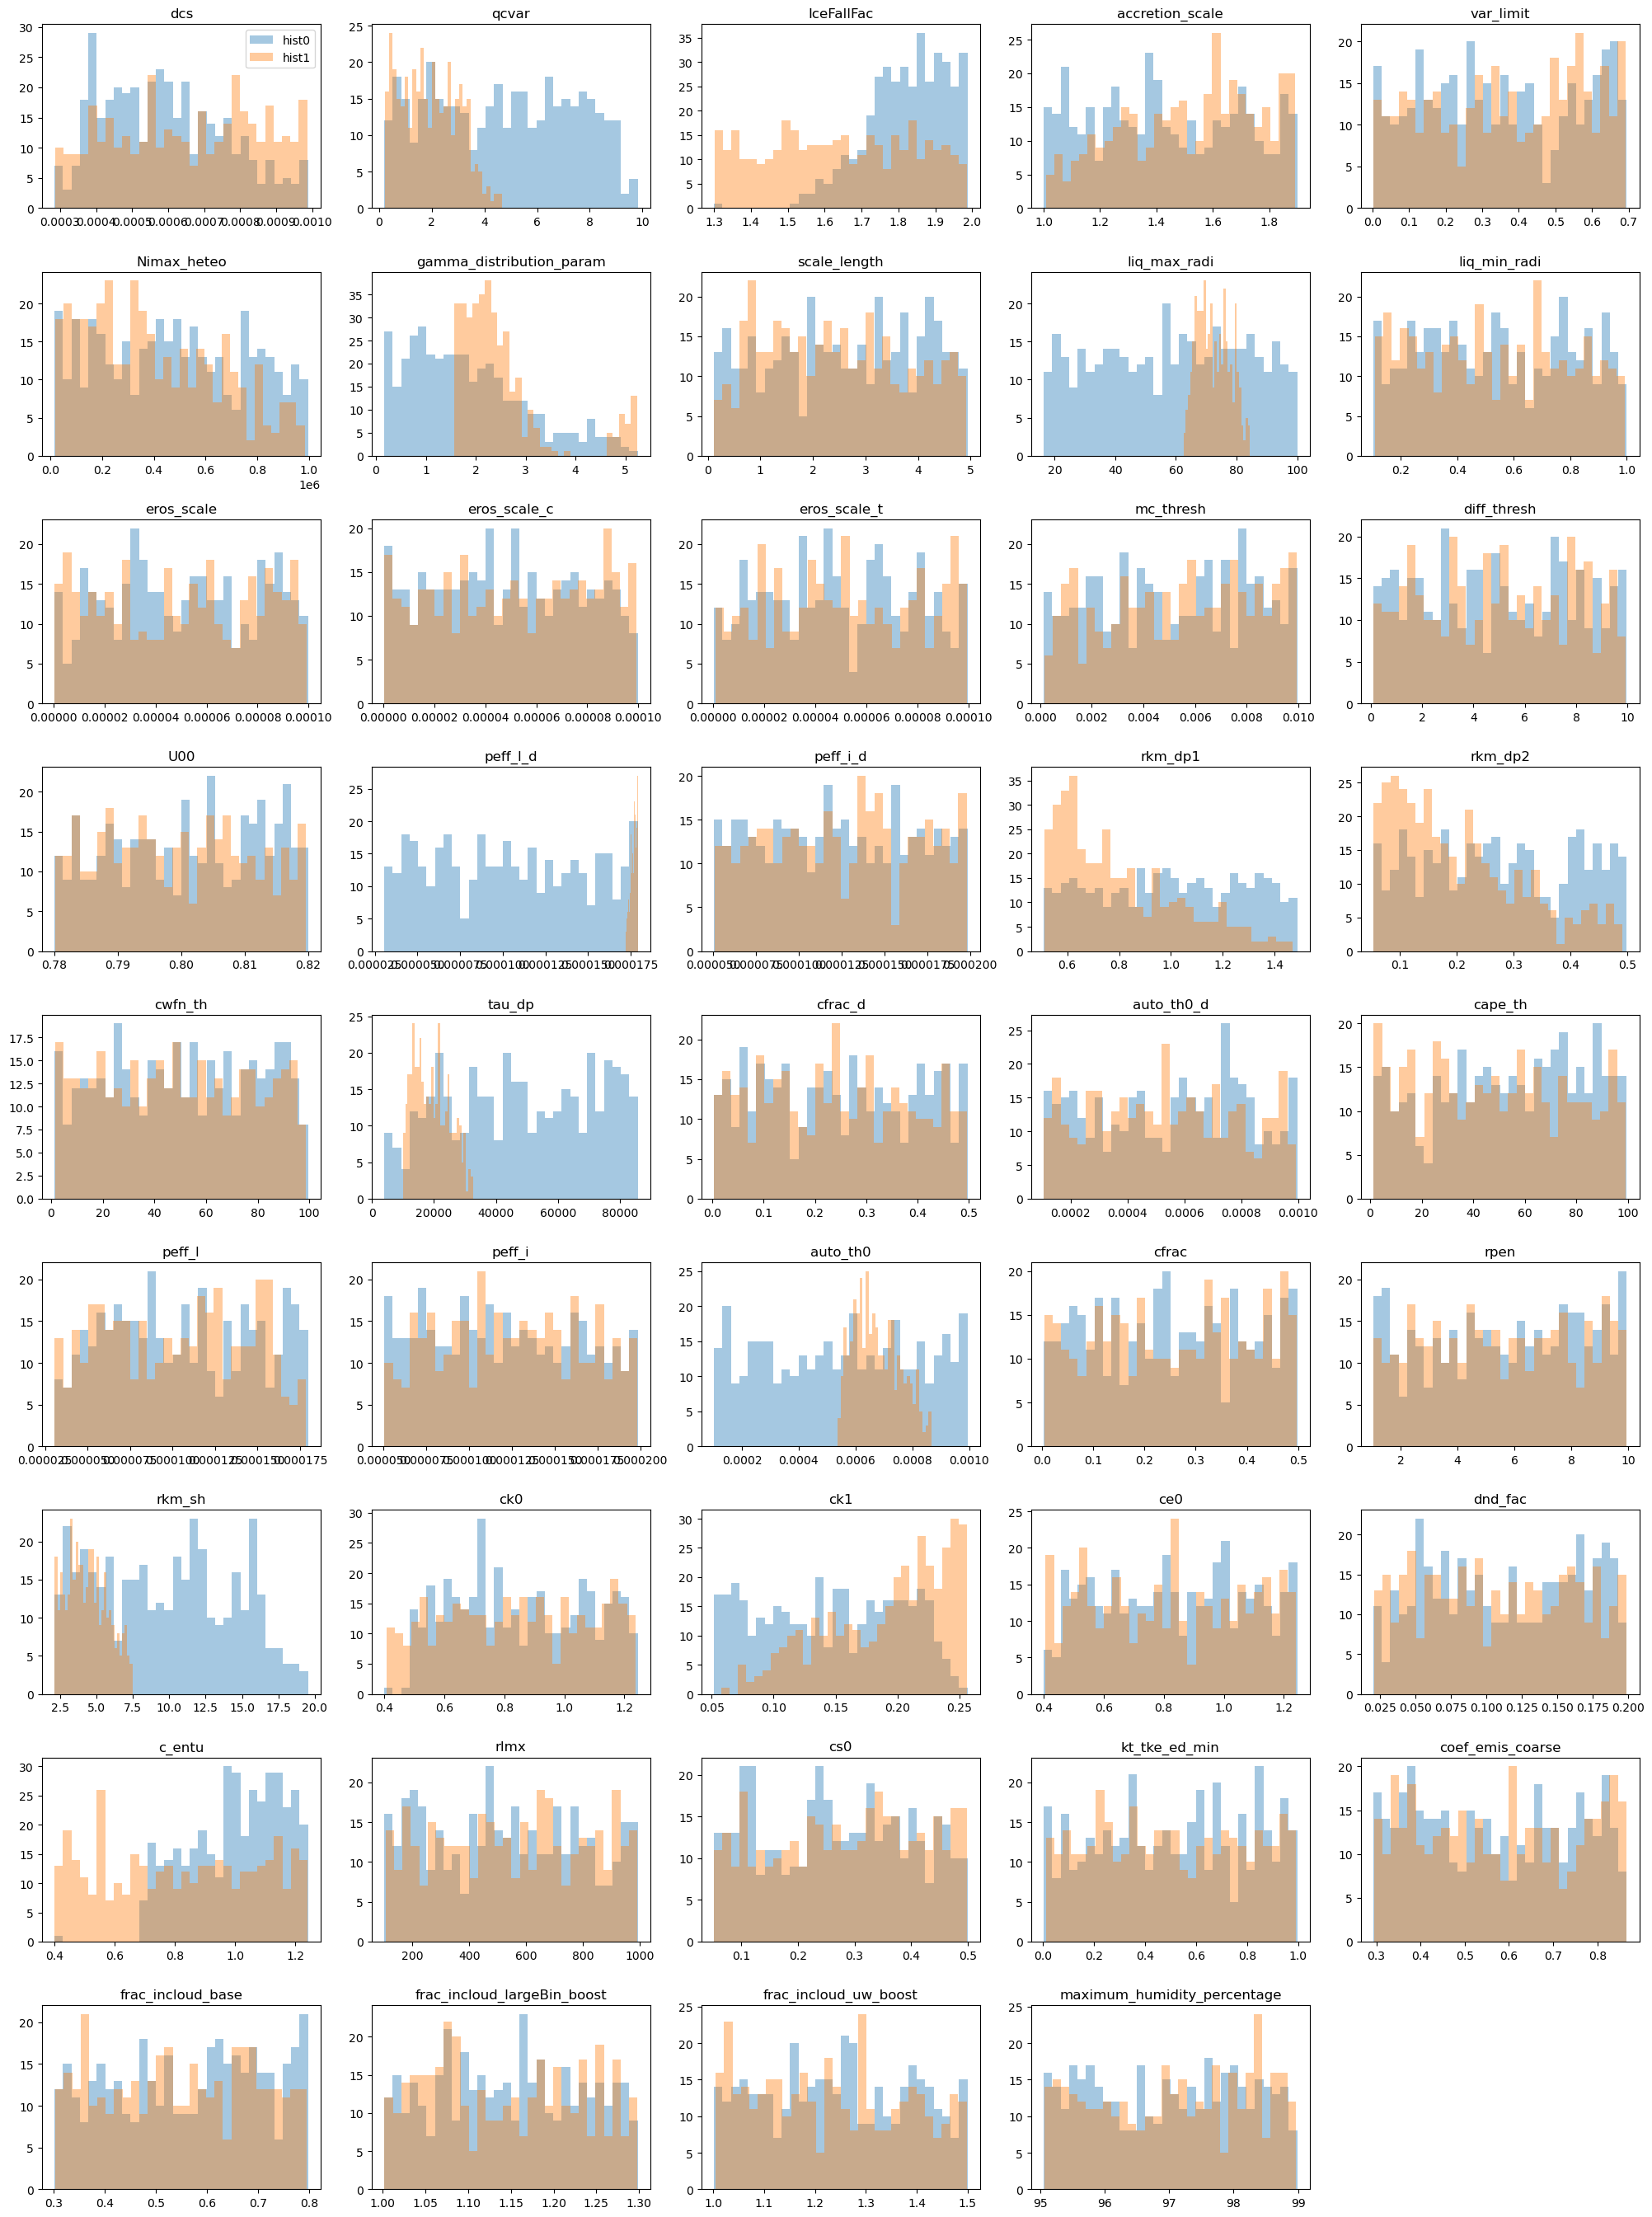

In [27]:
plot_histograms_grid_5([ppe_para, test_case.results.realscale_samples.iloc[:1000,:]])